# Exploratory Data Analysis — 2025-26 Premier League Scouting Dataset

Working from `backend/data/processed/players_clean.csv` (2,311 players across the Big 5 European leagues, 512 of them Premier League). This notebook answers the questions that should shape the modeling approach in Phase 4-6: who's valuable, how age and position relate to value, whether the minimum-minutes threshold is justified, and which stats actually correlate with market value.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

df = pd.read_csv("../backend/data/processed/players_clean.csv")
df.shape

Matplotlib is building the font cache; this may take a moment.


(2311, 109)

## Dataset overview

In [2]:
print("Total players:", len(df))
print("Premier League players:", df["is_premier_league"].sum())
print("Meet 900-minute threshold:", df["meets_minutes_threshold"].sum())
print()
print("By competition:")
print(df["Comp"].value_counts())
print()
print("By position group:")
print(df["position_group"].value_counts())

Total players: 2311
Premier League players: 512
Meet 900-minute threshold: 1452

By competition:
Comp
eng Premier League    512
it Serie A            486
es La Liga            444
de Bundesliga         439
fr Ligue 1            430
Name: count, dtype: int64

By position group:
position_group
MF    1019
DF     697
FW     411
GK     184
Name: count, dtype: int64


## Who has the highest market values?

Restricted to Premier League players, since that's the product's scope.

In [3]:
pl = df[df["is_premier_league"]].copy()
top15 = pl.sort_values("market_value_in_eur", ascending=False).head(15)
top15[["Player", "Squad", "position_group", "Age", "Min", "market_value_in_eur"]]

,Player,Squad,position_group,Age,Min,market_value_in_eur
986,Erling Haaland,Manchester City,FW,25.0,2953,200000000
790,Declan Rice,Arsenal,MF,26.0,3094,120000000
1021,Bukayo Saka,Arsenal,FW,23.0,2222,110000000
1366,Cole Palmer,Chelsea,MF,23.0,1955,100000000
1446,Florian Wirtz,Liverpool,MF,22.0,2378,100000000
1656,Moisés Caicedo,Chelsea,MF,23.0,2795,100000000
1060,Dominik Szoboszlai,Liverpool,MF,24.0,3231,100000000
1181,William Saliba,Arsenal,DF,24.0,2614,100000000
1206,Morgan Rogers,Aston Villa,MF,23.0,3280,90000000
1463,Rayan Cherki,Manchester City,MF,21.0,1786,90000000


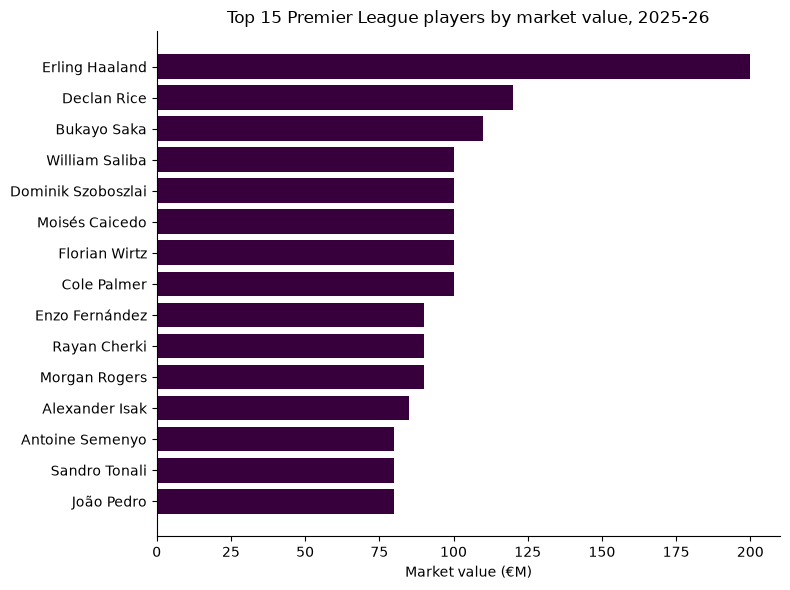

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
order = top15.sort_values("market_value_in_eur")
ax.barh(order["Player"], order["market_value_in_eur"] / 1e6, color="#37003c")
ax.set_xlabel("Market value (€M)")
ax.set_title("Top 15 Premier League players by market value, 2025-26")
plt.tight_layout()
plt.show()

## Market value distribution

Market value is expected to be heavily right-skewed — a handful of superstars, a long tail of squad players. This is why the model target will be `log1p(market_value_in_eur)` rather than raw euros.

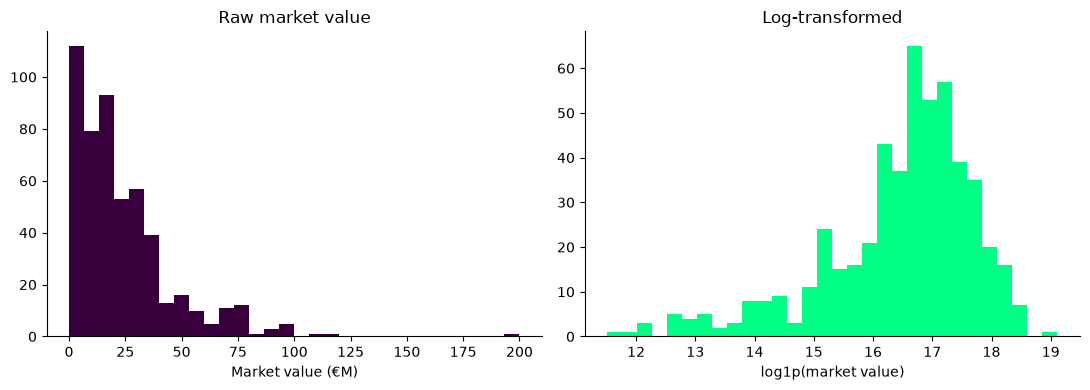

count    5.120000e+02
mean     2.416875e+07
std      2.282776e+07
min      1.000000e+05
25%      8.000000e+06
50%      1.800000e+07
75%      3.000000e+07
max      2.000000e+08
Name: market_value_in_eur, dtype: float64

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(pl["market_value_in_eur"] / 1e6, bins=30, color="#37003c")
axes[0].set_xlabel("Market value (€M)")
axes[0].set_title("Raw market value")

axes[1].hist(np.log1p(pl["market_value_in_eur"]), bins=30, color="#00ff85")
axes[1].set_xlabel("log1p(market value)")
axes[1].set_title("Log-transformed")
plt.tight_layout()
plt.show()

pl["market_value_in_eur"].describe()

## Which positions are most valuable?

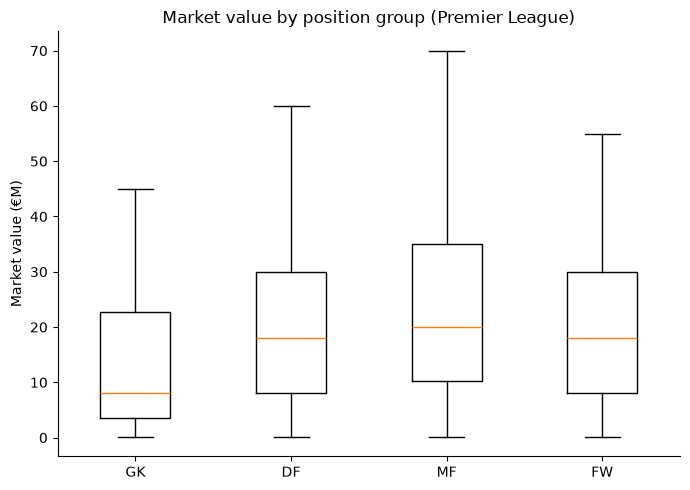

position_group
GK     8.0
DF    18.0
MF    20.0
FW    18.0
Name: market_value_in_eur, dtype: float64

In [6]:
order = ["GK", "DF", "MF", "FW"]
fig, ax = plt.subplots(figsize=(7, 5))
data = [pl[pl["position_group"] == p]["market_value_in_eur"] / 1e6 for p in order]
ax.boxplot(data, tick_labels=order, showfliers=False)
ax.set_ylabel("Market value (€M)")
ax.set_title("Market value by position group (Premier League)")
plt.tight_layout()
plt.show()

pl.groupby("position_group")["market_value_in_eur"].median().reindex(order) / 1e6

## How does age relate to value?

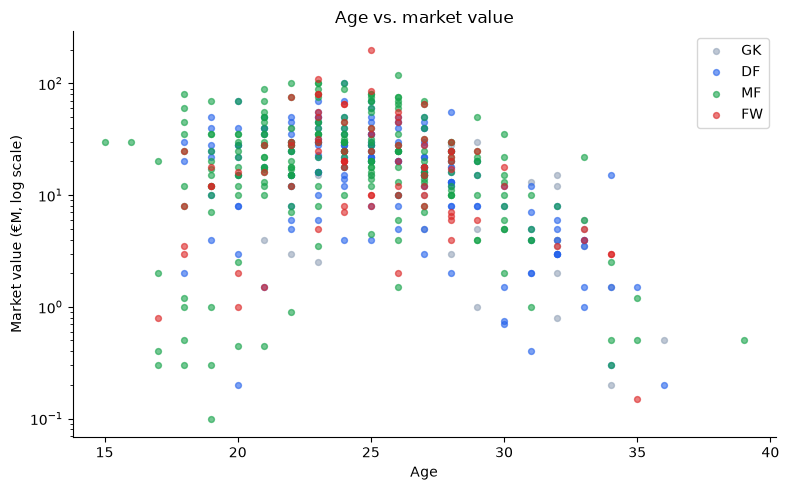

Age
(15, 20]    15.0
(20, 23]    28.0
(23, 26]    28.0
(26, 29]    16.0
(29, 32]     5.0
(32, 40]     1.5
Name: market_value_in_eur, dtype: float64

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {"GK": "#94a3b8", "DF": "#2563eb", "MF": "#16a34a", "FW": "#dc2626"}
for pos, c in colors.items():
    sub = pl[pl["position_group"] == pos]
    ax.scatter(sub["Age"], sub["market_value_in_eur"] / 1e6, s=18, alpha=0.6, label=pos, color=c)
ax.set_yscale("log")
ax.set_xlabel("Age")
ax.set_ylabel("Market value (€M, log scale)")
ax.set_title("Age vs. market value")
ax.legend()
plt.tight_layout()
plt.show()

pl.groupby(pd.cut(pl["Age"], bins=[15, 20, 23, 26, 29, 32, 40]))["market_value_in_eur"].median() / 1e6

## How do minutes affect per-90 stat reliability?

This is the justification for the 900-minute threshold: with few minutes played, a single goal or card produces an extreme, unrepresentative per-90 rate. Using the full 2,311-player set (more data points for this specific check).

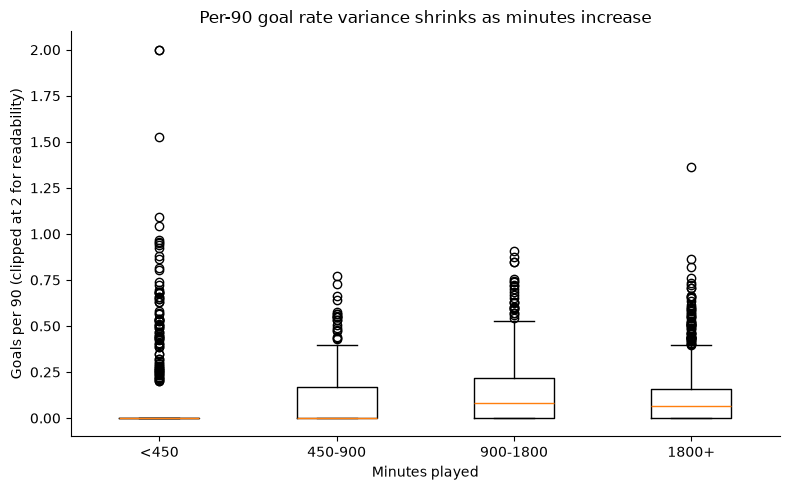

,mean,std,count
minutes_bucket,,,
<450,0.089943,0.246164,515
450-900,0.105665,0.153769,345
900-1800,0.142379,0.168066,663
1800+,0.121071,0.160420,788


In [8]:
tmp = df.copy()
tmp["gls_per90"] = tmp["Gls"] / (tmp["Min"] / 90)
bins = [0, 450, 900, 1800, 4000]
labels = ["<450", "450-900", "900-1800", "1800+"]
tmp["minutes_bucket"] = pd.cut(tmp["Min"], bins=bins, labels=labels)

fig, ax = plt.subplots(figsize=(8, 5))
data = [tmp[tmp["minutes_bucket"] == b]["gls_per90"].clip(upper=2) for b in labels]
ax.boxplot(data, tick_labels=labels)
ax.set_ylabel("Goals per 90 (clipped at 2 for readability)")
ax.set_xlabel("Minutes played")
ax.set_title("Per-90 goal rate variance shrinks as minutes increase")
plt.tight_layout()
plt.show()

tmp.groupby("minutes_bucket", observed=True)["gls_per90"].agg(["mean", "std", "count"])

## Which statistics correlate most with valuation?

Using only players who meet the minutes threshold, so correlations reflect real signal rather than small-sample noise.

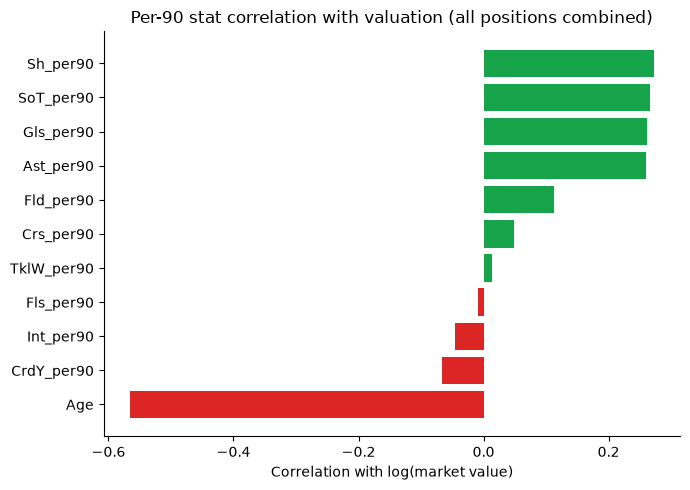

In [9]:
reliable = df[df["meets_minutes_threshold"]].copy()
per90_cols = ["Gls", "Ast", "Sh", "SoT", "Crs", "Int", "TklW", "Fls", "Fld", "CrdY"]
for c in per90_cols:
    reliable[f"{c}_per90"] = reliable[c] / (reliable["Min"] / 90)

reliable["log_value"] = np.log1p(reliable["market_value_in_eur"])
corr_cols = [f"{c}_per90" for c in per90_cols] + ["Age"]
corrs = reliable[corr_cols + ["log_value"]].corr()["log_value"].drop("log_value").sort_values()

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(corrs.index, corrs.values, color=["#dc2626" if v < 0 else "#16a34a" for v in corrs.values])
ax.set_xlabel("Correlation with log(market value)")
ax.set_title("Per-90 stat correlation with valuation (all positions combined)")
plt.tight_layout()
plt.show()

Note: correlating raw per-90 stats against value **across all positions combined** partly measures "which positions are valuable" rather than "which actions are valuable" — e.g. tackles won correlating negatively mostly reflects that defenders are, on average, valued lower than attackers, not that tackling reduces a player's worth. This is exactly why the valuation model needs position as a feature (Phase 6), rather than one global formula.

## Outliers: high output, low value (and vice versa)

A first, crude look before any model exists — sorting by goal contributions per 90 among highly-valued vs. low-valued reliable-minutes players.

In [10]:
reliable["ga_per90"] = (reliable["Gls"] + reliable["Ast"]) / (reliable["Min"] / 90)
attackers = reliable[reliable["position_group"].isin(["MF", "FW"])]

print("High output, low value (potential undervaluation signal):")
print(attackers.sort_values("ga_per90", ascending=False).head(15)
      [["Player", "Squad", "Comp", "ga_per90", "market_value_in_eur"]]
      .sort_values("market_value_in_eur").head(8).to_string(index=False))

High output, low value (potential undervaluation signal):
           Player               Squad          Comp  ga_per90  market_value_in_eur
        Ansu Fati              Monaco    fr Ligue 1  0.905764             15000000
     Serge Gnabry       Bayern Munich de Bundesliga  1.033634             18000000
      Deniz Undav           Stuttgart de Bundesliga  1.044177             22000000
Ermedin Demirović           Stuttgart de Bundesliga  0.901804             22000000
Jonathan Burkardt Eintracht Frankfurt de Bundesliga  0.943114             30000000
         Can Uzun Eintracht Frankfurt de Bundesliga  0.934256             45000000
    Marcus Thuram               Inter    it Serie A  0.900000             50000000
       Harry Kane       Bayern Munich de Bundesliga  1.552377             60000000


## Key takeaways

- **Age dominates the raw correlations.** Age correlates with log(market value) at -0.57 — far stronger than any single performance stat. Median value peaks for 20-26 year-olds (~€28M) and declines sharply after 29. This confirms age has to be a first-class model feature, not an afterthought: two players with identical output at 21 and 31 should not get the same expected value.
- **Attacking output correlates moderately (~0.26-0.27), defensive actions barely at all (~0.01 to -0.05) when pooled across all positions.** This is the position confound flagged above, not evidence that defending doesn't matter — it's evidence that a single global regression would be misleading. Confirms the plan to include position as a model feature.
- **Position medians are closer than expected**: GK €8M, DF €18M, MF €20M, FW €18M. Midfielders edge out forwards at the median in this dataset, likely reflecting how many high-value deep-lying/creative midfielders (Rice, Caicedo, Szoboszlai, Palmer) sit in the £75-120M range.
- **The minutes threshold is justified, but not by a perfectly clean trend.** The under-450-minute bucket has the highest per-90 goal-rate variance (std 0.246, clearly the outlier), which is the core justification for 900 minutes. The pattern above that isn't perfectly monotonic (900-1800 min: std 0.168 vs. 1800+: std 0.160) — likely reflects differences in *who* falls into each bucket (e.g. more high-usage attacking substitutes in the middle bucket) rather than sample size alone. Worth being honest about rather than overclaiming a clean statistical story.
- **The crude high-output/low-value scan already surfaces plausible names** (Ansu Fati, Serge Gnabry, Harry Kane at a relatively "low" €60M) — a preview of what Phase 7's model-based undervaluation ranking should formalize properly, scoped to the Premier League and adjusted for position and age rather than this raw, unscoped pass.